In [ ]:
# A_EDA.ipynb
## Exploratory Data Analysis for F1 Tyre Strategy / Lap Time Dataset

#This notebook performs exploratory data analysis on the processed master dataset.

### Goals
#Understand dataset shape and columns
#Check missing values and duplicates
#Study distributions of tyre compound, drivers, teams, lap times, tyre life
#Inspect   numerical relationships and correlations
#Generate figures for the research paper

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [6]:
DATA_PATH = Path("../data/processed/master_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (11880, 14)


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1,83.186,0.984848,0.100,0,0,16.0
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1,79.871,0.969697,0.125,0,0,25.0
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1,79.364,0.954545,0.150,0,0,36.0
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1,80.766,0.939394,0.175,0,0,49.0
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1,80.827,0.924242,0.200,0,0,64.0


In [7]:
for col in df.columns:
    print(col)

Driver
Team
LapNumber
Compound
TyreLife
Stint
Position
TrackStatus
LapTimeSeconds
FuelLoadApprox
StintProgress
CompoundEncoded
FreshTyre
TyreAgeSquared


In [8]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (11880, 14)

Columns:
['Driver', 'Team', 'LapNumber', 'Compound', 'TyreLife', 'Stint', 'Position', 'TrackStatus', 'LapTimeSeconds', 'FuelLoadApprox', 'StintProgress', 'CompoundEncoded', 'FreshTyre', 'TyreAgeSquared']

Data types:
Driver                 str
Team                   str
LapNumber          float64
Compound               str
TyreLife           float64
Stint              float64
Position           float64
TrackStatus          int64
LapTimeSeconds     float64
FuelLoadApprox     float64
StintProgress      float64
CompoundEncoded      int64
FreshTyre            int64
TyreAgeSquared     float64
dtype: object

First 5 rows:


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1,83.186,0.984848,0.100,0,0,16.0
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1,79.871,0.969697,0.125,0,0,25.0
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1,79.364,0.954545,0.150,0,0,36.0
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1,80.766,0.939394,0.175,0,0,49.0
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1,80.827,0.924242,0.200,0,0,64.0


In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values per column:")
display(missing)

if len(missing) == 0:
    print("No missing values found.")

Missing values per column:


Series([], dtype: int64)

No missing values found.


In [10]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
display(df.describe(include="all"))

,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
count,11880,11880,11880.000000,11880,11880.000000,11880.000000,11880.000000,11880.0,11880.000000,11880.000000,11880.000000,11880.000000,11880.000000,11880.000000
unique,26,12,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,RUS,Mercedes,NaN,HARD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,632,1262,NaN,4896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,30.013973,NaN,12.639983,2.060017,10.013973,1.0,91.993103,0.545243,0.388595,1.147896,0.031650,224.071633
std,NaN,NaN,17.184366,NaN,8.019219,0.867529,5.555055,0.0,9.159013,0.260369,0.239234,0.809030,0.175073,271.707677
min,NaN,NaN,1.000000,NaN,1.000000,1.000000,1.000000,1.0,76.330000,0.000000,0.020000,0.000000,0.000000,1.000000
25%,NaN,NaN,15.000000,NaN,6.000000,1.000000,5.000000,1.0,84.915750,0.333333,0.195122,0.000000,0.000000,36.000000
50%,NaN,NaN,30.000000,NaN,11.000000,2.000000,10.000000,1.0,89.990000,0.545455,0.354839,1.000000,0.000000,121.000000
75%,NaN,NaN,44.000000,NaN,17.000000,3.000000,15.000000,1.0,98.749500,0.772727,0.542857,2.000000,0.000000,289.000000


In [12]:
categorical_cols = ["Driver", "Team", "Compound", "TrackStatus", "FreshTyre"]

for col in categorical_cols:
    print(f"\n{col} unique values ({df[col].nunique()}):")
    print(df[col].unique())


Driver unique values (26):
<ArrowStringArray>
['VER', 'NOR', 'HAM', 'RUS', 'LEC', 'SAI', 'PIA', 'PER', 'GAS', 'OCO', 'HUL',
 'ALO', 'ZHO', 'STR', 'RIC', 'BOT', 'MAG', 'ALB', 'TSU', 'SAR', 'COL', 'DEV',
 'VET', 'MSC', 'LAT', 'LAW']
Length: 26, dtype: str

Team unique values (12):
<ArrowStringArray>
['Red Bull Racing',         'McLaren',        'Mercedes',         'Ferrari',
          'Alpine',    'Haas F1 Team',    'Aston Martin',     'Kick Sauber',
              'RB',        'Williams',      'Alfa Romeo',      'AlphaTauri']
Length: 12, dtype: str

Compound unique values (3):
<ArrowStringArray>
['SOFT', 'MEDIUM', 'HARD']
Length: 3, dtype: str

TrackStatus unique values (1):
[1]

FreshTyre unique values (2):
[0 1]


In [13]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:")
print(num_cols)

Numerical columns:
['LapNumber', 'TyreLife', 'Stint', 'Position', 'TrackStatus', 'LapTimeSeconds', 'FuelLoadApprox', 'StintProgress', 'CompoundEncoded', 'FreshTyre', 'TyreAgeSquared']


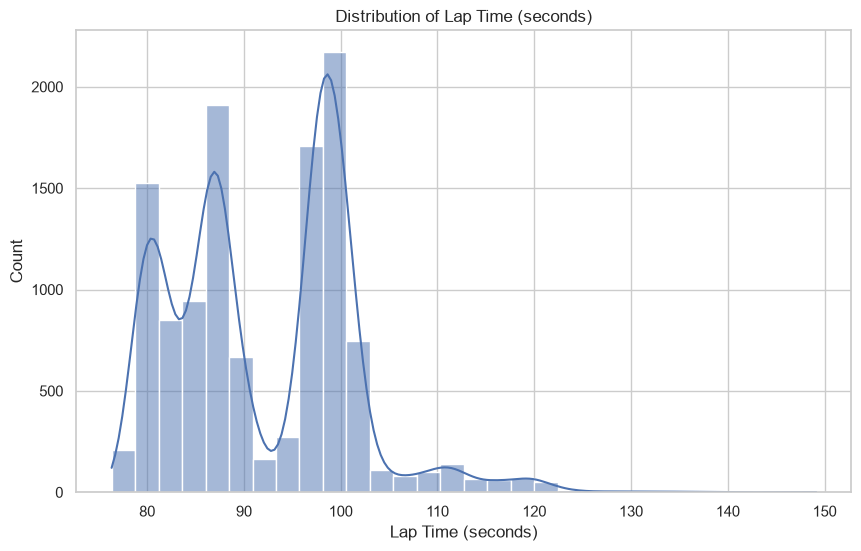

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df["LapTimeSeconds"], bins=30, kde=True)
plt.title("Distribution of Lap Time (seconds)")
plt.xlabel("Lap Time (seconds)")
plt.ylabel("Count")
plt.show()

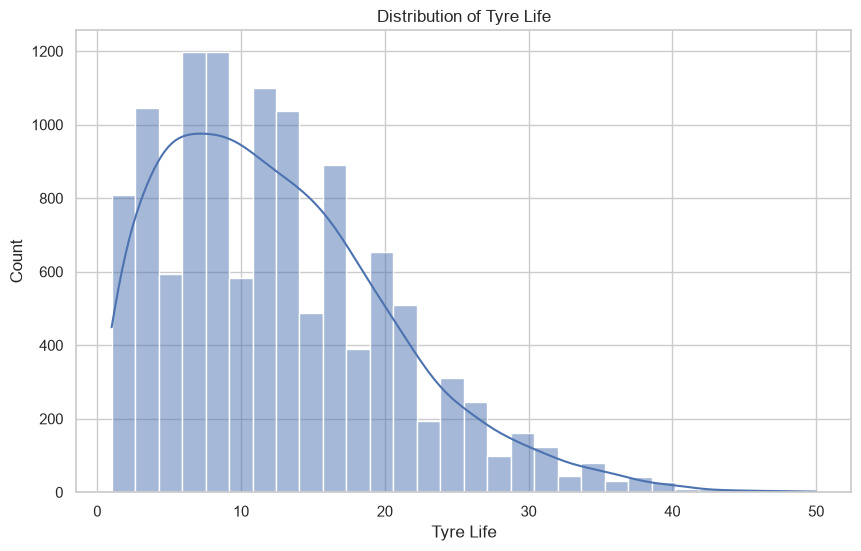

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df["TyreLife"], bins=30, kde=True)
plt.title("Distribution of Tyre Life")
plt.xlabel("Tyre Life")
plt.ylabel("Count")
plt.show()

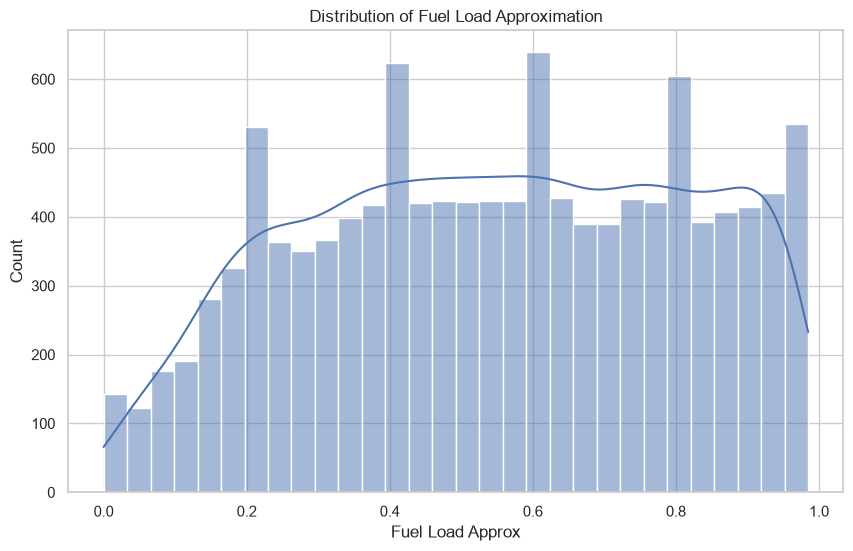

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df["FuelLoadApprox"], bins=30, kde=True)
plt.title("Distribution of Fuel Load Approximation")
plt.xlabel("Fuel Load Approx")
plt.ylabel("Count")
plt.show()

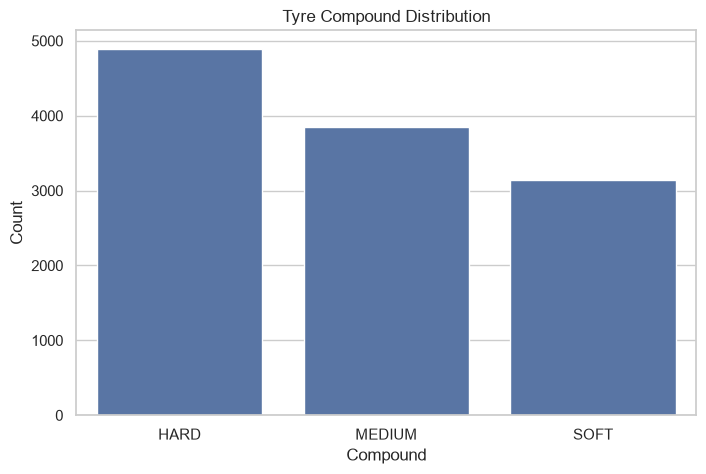

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Compound", order=df["Compound"].value_counts().index)
plt.title("Tyre Compound Distribution")
plt.xlabel("Compound")
plt.ylabel("Count")
plt.show()

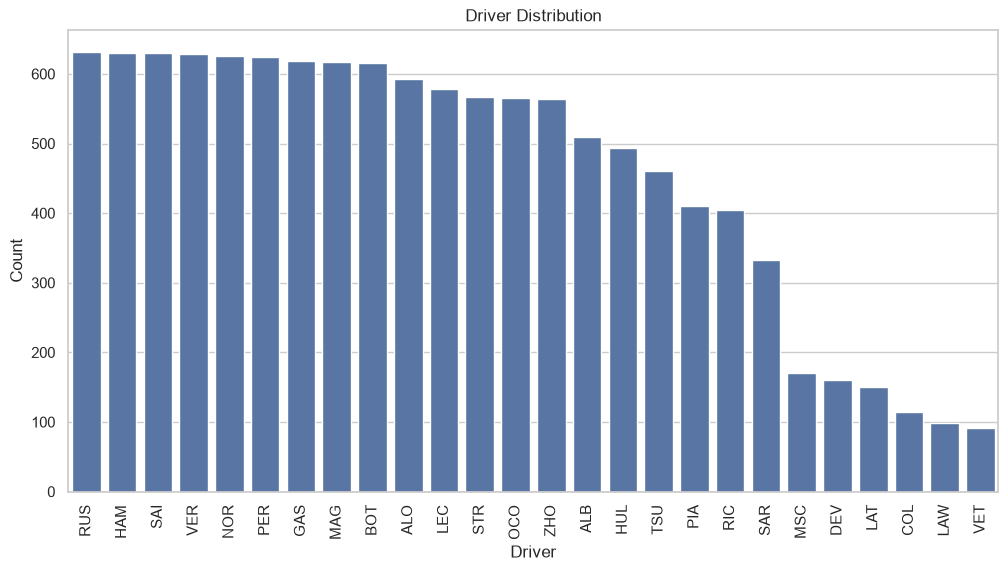

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Driver", order=df["Driver"].value_counts().index)
plt.title("Driver Distribution")
plt.xlabel("Driver")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

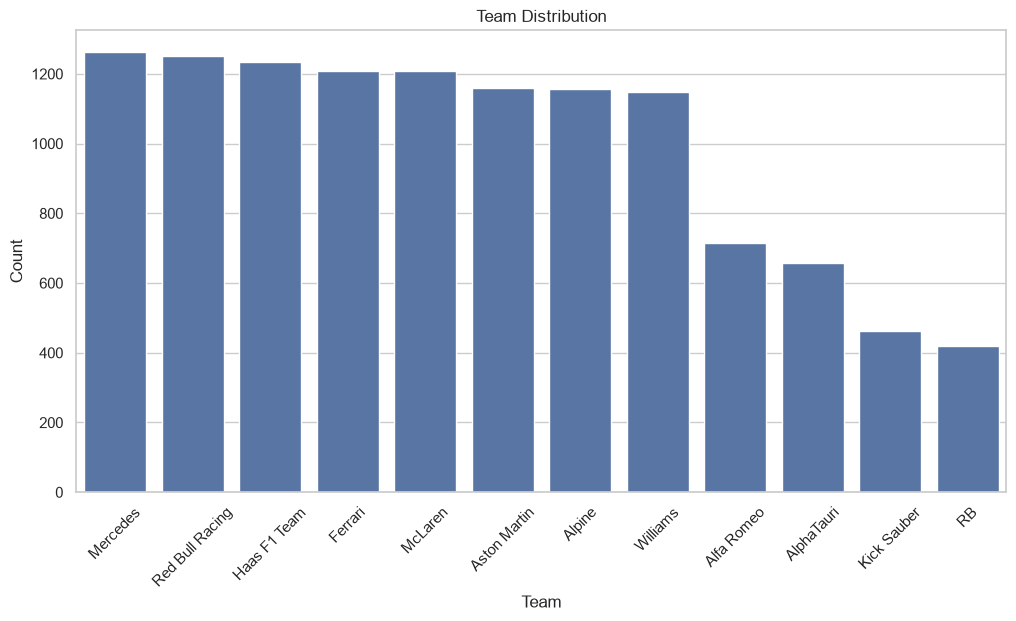

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Team", order=df["Team"].value_counts().index)
plt.title("Team Distribution")
plt.xlabel("Team")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

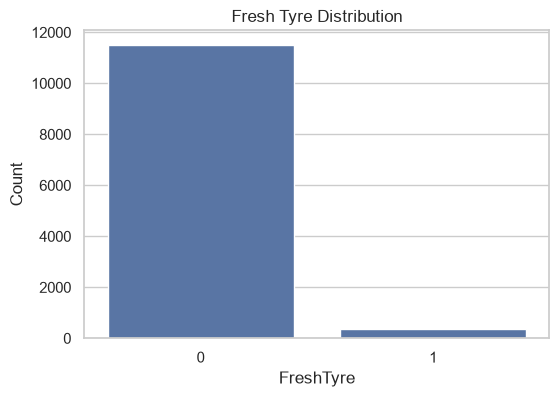

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="FreshTyre")
plt.title("Fresh Tyre Distribution")
plt.xlabel("FreshTyre")
plt.ylabel("Count")
plt.show()

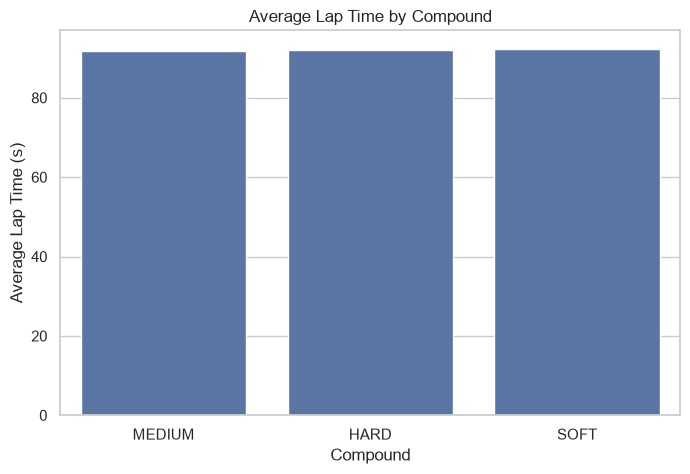

Compound
MEDIUM    91.701318
HARD      91.973201
SOFT      92.381558
Name: LapTimeSeconds, dtype: float64

In [21]:
compound_laptime = df.groupby("Compound")["LapTimeSeconds"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=compound_laptime.index, y=compound_laptime.values)
plt.title("Average Lap Time by Compound")
plt.xlabel("Compound")
plt.ylabel("Average Lap Time (s)")
plt.show()

display(compound_laptime)

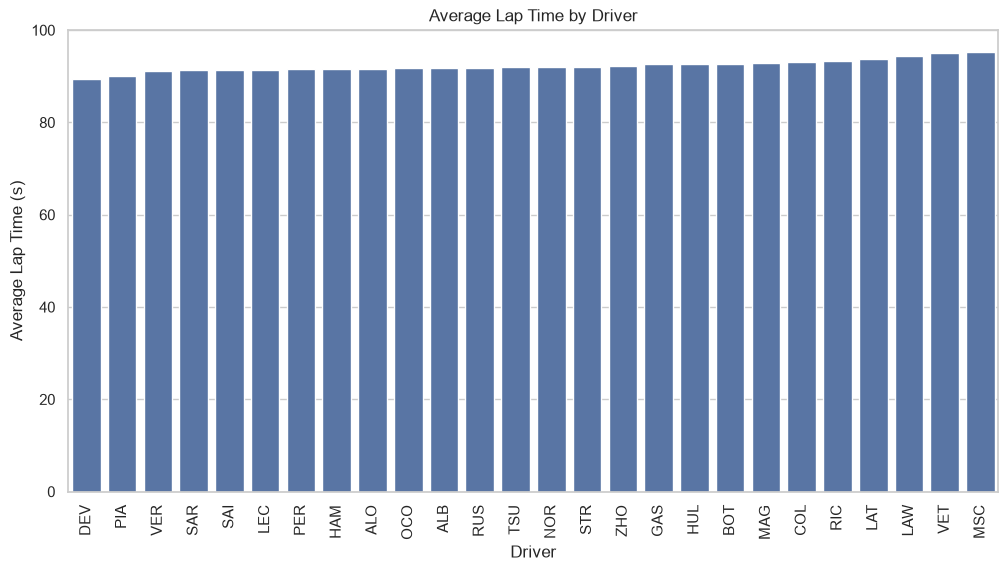

In [22]:
driver_laptime = df.groupby("Driver")["LapTimeSeconds"].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(x=driver_laptime.index, y=driver_laptime.values)
plt.title("Average Lap Time by Driver")
plt.xlabel("Driver")
plt.ylabel("Average Lap Time (s)")
plt.xticks(rotation=90)
plt.show()

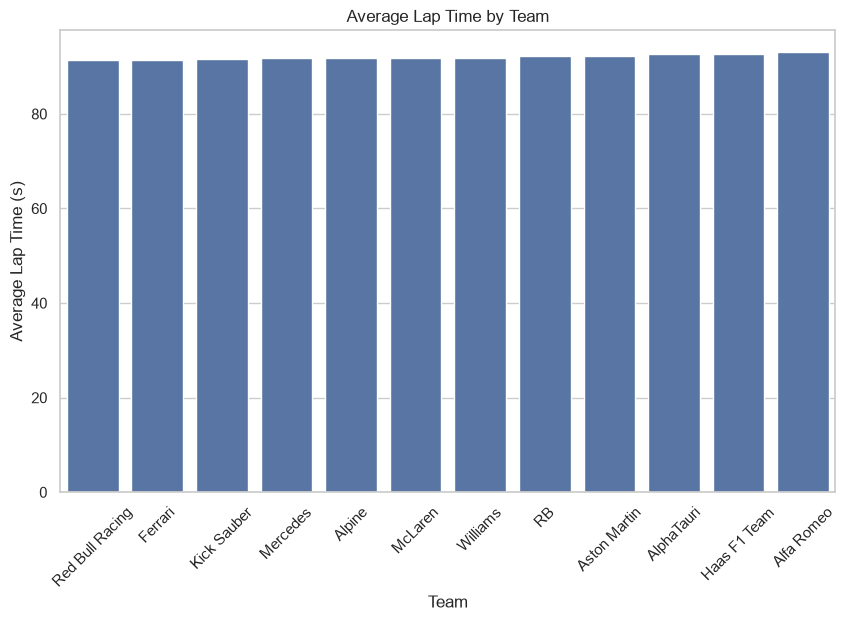

In [23]:
team_laptime = df.groupby("Team")["LapTimeSeconds"].mean().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(x=team_laptime.index, y=team_laptime.values)
plt.title("Average Lap Time by Team")
plt.xlabel("Team")
plt.ylabel("Average Lap Time (s)")
plt.xticks(rotation=45)
plt.show()

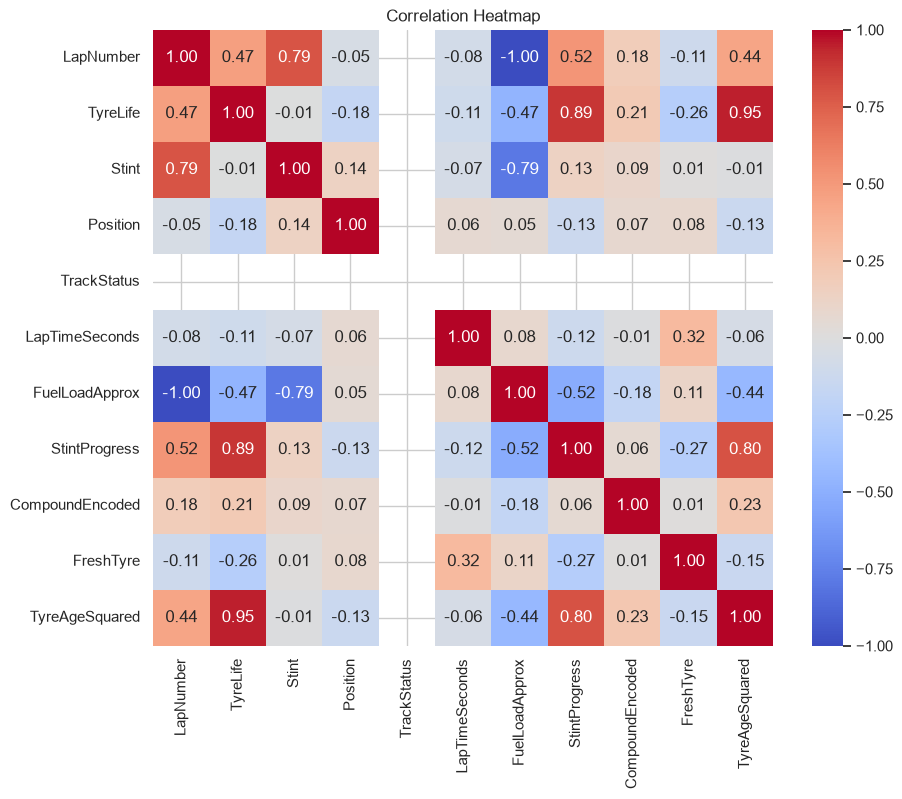

In [24]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

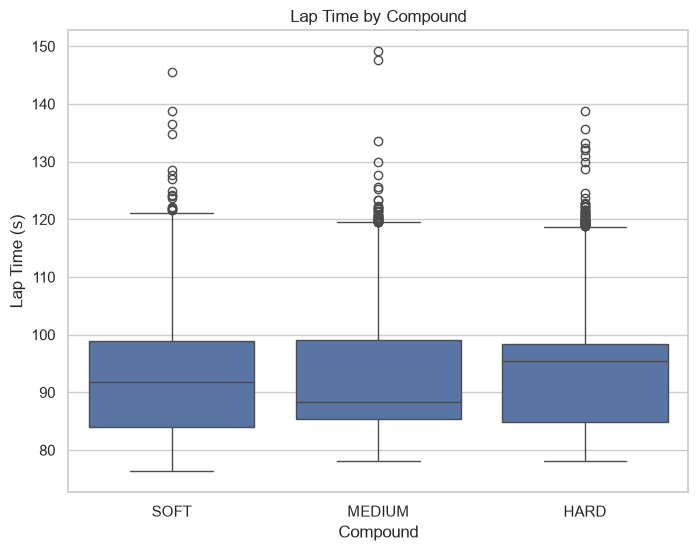

In [25]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Compound", y="LapTimeSeconds")
plt.title("Lap Time by Compound")
plt.xlabel("Compound")
plt.ylabel("Lap Time (s)")
plt.show()

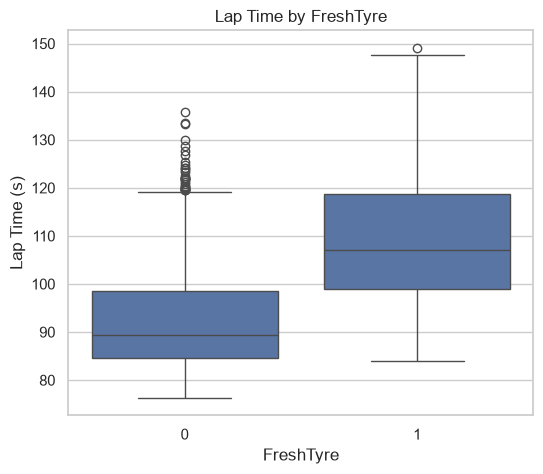

In [26]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x="FreshTyre", y="LapTimeSeconds")
plt.title("Lap Time by FreshTyre")
plt.xlabel("FreshTyre")
plt.ylabel("Lap Time (s)")
plt.show()

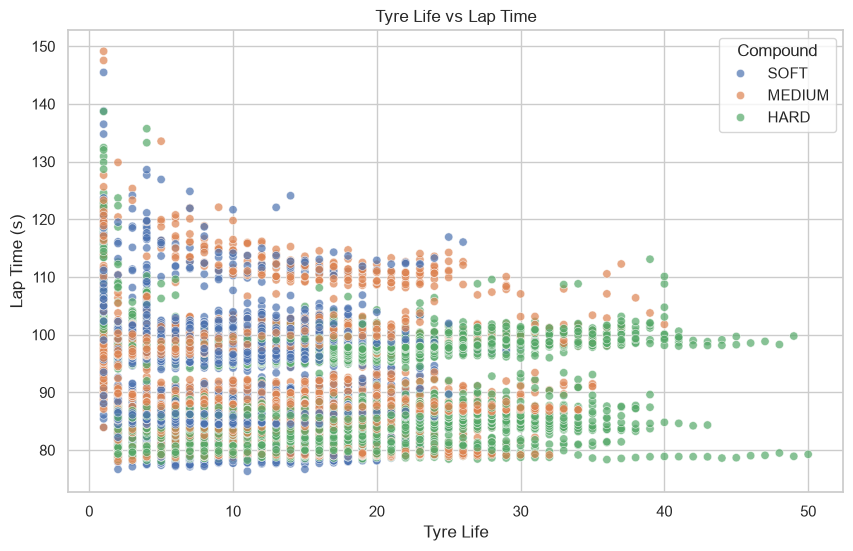

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="TyreLife", y="LapTimeSeconds", hue="Compound", alpha=0.7)
plt.title("Tyre Life vs Lap Time")
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (s)")
plt.show()

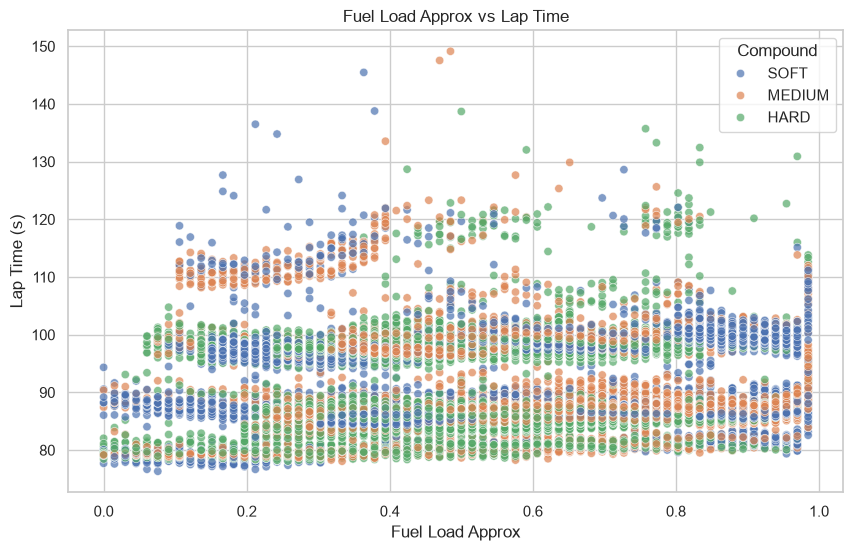

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="FuelLoadApprox", y="LapTimeSeconds", hue="Compound", alpha=0.7)
plt.title("Fuel Load Approx vs Lap Time")
plt.xlabel("Fuel Load Approx")
plt.ylabel("Lap Time (s)")
plt.show()

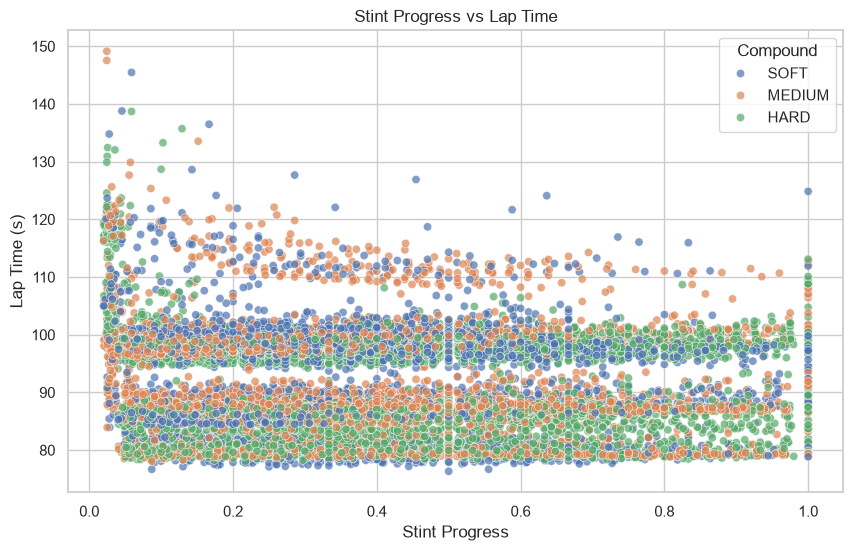

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="StintProgress", y="LapTimeSeconds", hue="Compound", alpha=0.7)
plt.title("Stint Progress vs Lap Time")
plt.xlabel("Stint Progress")
plt.ylabel("Lap Time (s)")
plt.show()

In [30]:
Q1 = df["LapTimeSeconds"].quantile(0.25)
Q3 = df["LapTimeSeconds"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["LapTimeSeconds"] < lower) | (df["LapTimeSeconds"] > upper)]

print("Number of LapTimeSeconds outliers:", len(outliers))
display(outliers.head())

Number of LapTimeSeconds outliers: 102


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
1834,HUL,Haas F1 Team,30.0,HARD,1.0,2.0,10.0,1,121.641,0.545455,0.025000,2,1,1.0
1956,COL,Williams,30.0,HARD,1.0,2.0,13.0,1,121.584,0.545455,0.027027,2,1,1.0
2021,TSU,RB,34.0,SOFT,4.0,2.0,14.0,1,121.124,0.484848,0.129032,0,0,16.0
2078,OCO,Alpine,30.0,HARD,1.0,2.0,17.0,1,120.611,0.545455,0.031250,2,1,1.0
2136,STR,Aston Martin,27.0,MEDIUM,2.0,2.0,19.0,1,120.401,0.590909,0.055556,1,0,4.0


In [31]:
from pathlib import Path
fig_path = Path("../outputs/figures")
fig_path.mkdir(parents=True, exist_ok=True)

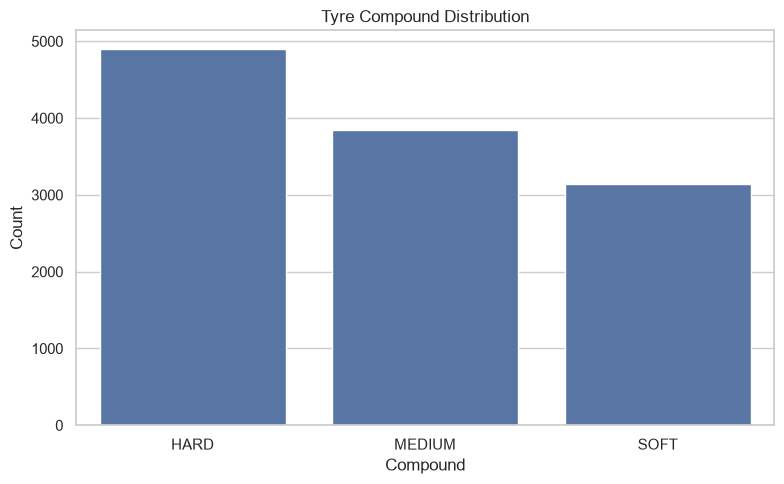

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Compound", order=df["Compound"].value_counts().index)
plt.title("Tyre Compound Distribution")
plt.xlabel("Compound")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_path / "compound_distribution.png", dpi=300)
plt.show()

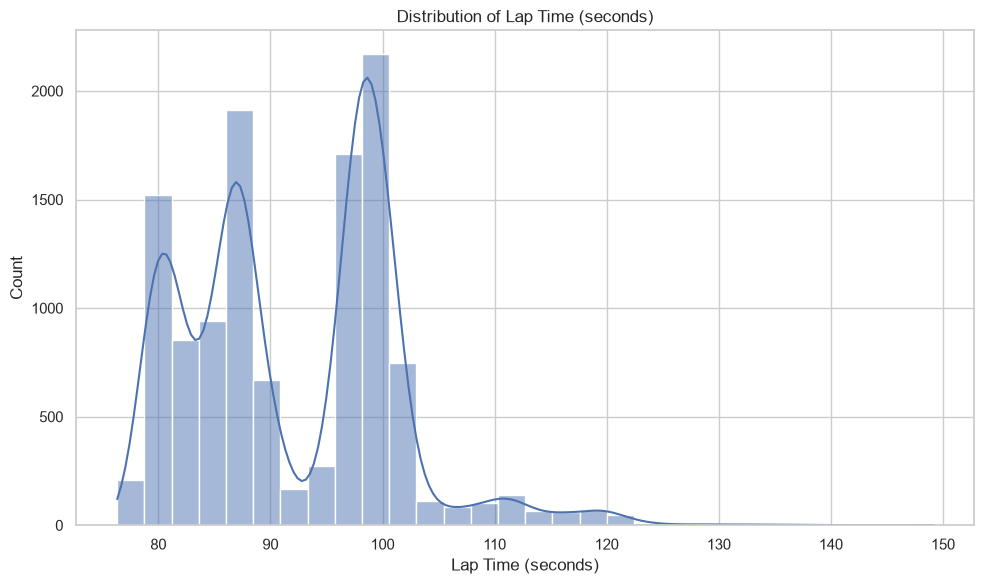

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(df["LapTimeSeconds"], bins=30, kde=True)
plt.title("Distribution of Lap Time (seconds)")
plt.xlabel("Lap Time (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig_path / "lap_time_distribution.png", dpi=300)
plt.show()

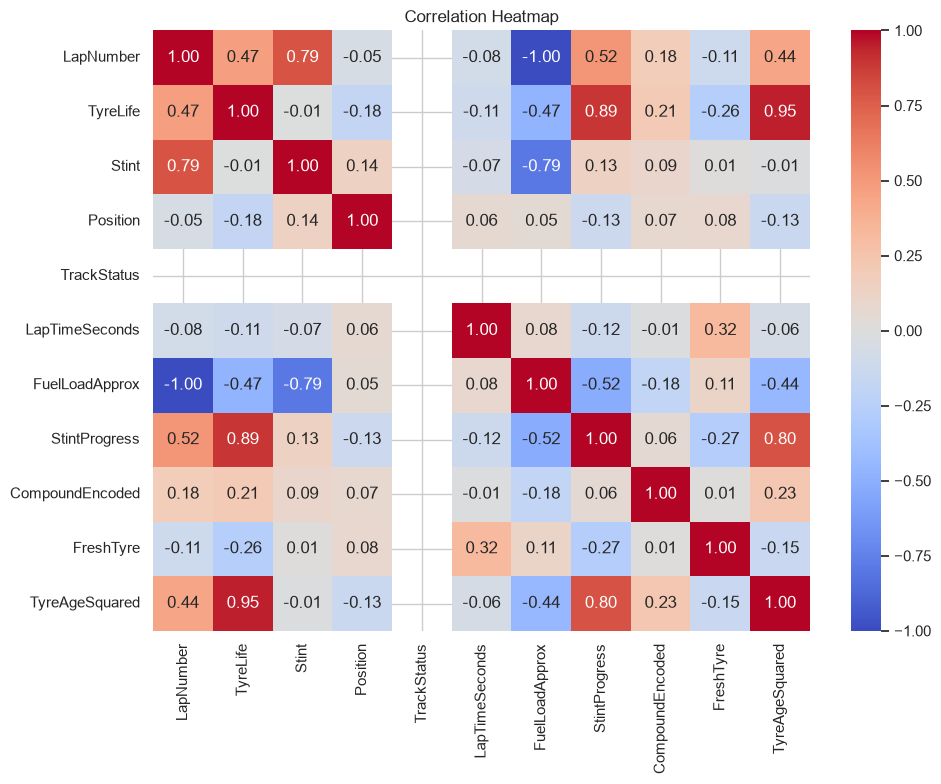

In [34]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(fig_path / "correlation_heatmap.png", dpi=300)
plt.show()